# Regression / Polynomial Regression – From Scratch

In this assignment, we want to predict *Total Sales* based on *TV Advertisement (X1)* and *Radio Advertisement (X2)* using the same dataset that we worked with in the lectures.  

We will start by building a **linear regression model** as a baseline, then extend it to a **polynomial regression model**, and finally compare the two models against each other.

## Step 0: Import Modules

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
Version=40.06

## Step 1: Setup dataset
1.    Download the dataset (Advertising.csv) from Canvas or directly from its Kaggle page, https://www.kaggle.com/ishaanv/ISLR-Auto and upload the data file  to your colab notebook
2.    Load the csv file to a DataFrame called data by running the following command

In [23]:
#Do NOT change this line
data=pd.read_csv('Advertising.csv')
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


## Step 2: Form the features

Define the following variables for the features and label.

*   'X1' for $$(TV Advertisement)$$
*   'X1_X1' for $$(TV Advertisement)^2$$
*   'X2' for $$(Radio Advertisement)$$
*   'X2_X2' for $$(Radio Advertisement)^2$$
*   'Y' for Sales


In [24]:
### BEGIN SOLUTION

X1= data['TV']
X1_X1= X1**2.0

X2= data['Radio']
X2_X2= X2**2.0

# This is the cross-term for the poly fit later
X1_X2 = X1*X2

Y= data['Sales']

### END SOLUTION

## Step 3: Normalization

Normalize the features and label using the features defined in the previous step and store them in the following variables:

* 'X1_N'
* 'X1_X1_N'
* 'X2_N'
* 'X2_X2_N'
* 'Y_N'

In [46]:
### BEGIN SOLUTION

def _norm(z: pd.Series) -> pd.Series:
    # This is not unit scaling, but z-scaling.
    # return (z - z.min()) / (z.max() - z.min())
    return (z - z.mean()) / (z.std())

X1_N= _norm(X1)
X1_X1_N = _norm(X1_X1)
X2_N = _norm(X2)
X2_X2_N = _norm(X2_X2)
X1_X2_N = _norm(X1_X2)
Y_N = _norm(Y)


### END SOLUTION

## Step 4: Linear regression (Baseline)

In all regression problems, we first try linear regression:

>$$Sales=\theta_0+\theta_1(TV Advertisement)+\theta_2(Radio Advertisement)$$

1.   In the code block below, we have a list named Linear_thetas that in this case should contain 3 values: $$\theta_0,\theta_1,\theta_2$$. Initialize the theta parameters by filling the values in the list selecting a number between 0 to 0.5 for all Thetas. You will have to change these values over and over till you get the result you want.

2.   Initialize the learning rate Linear_eta $$\eta$$ as a value between 0 and 0.1. You will have to change the learning rate over and over till you get the result you want.

3.  Form the loss function (Mean squared error) as below:

>>$J= \frac{1}{Data Size}\sum_{Data} (\hat{y}-y)^2$

>>>$\hat{y}$ is the predicted value

>>>$y$ is the actual value

4.  Form the deravatives of Loss (J) with respect to Thetas:

>>$Jt0 = \frac{dJ}{d\theta_0}$<br>
>>$Jt1 = \frac{dJ}{d\theta_1}$<br>
>>$Jt2 = \frac{dJ}{d\theta_2}$

5.  Form the iterative procedure in which Theta values are updated based on the derivatives (Gradient Descent).

<font color='red'> Important notes:


*   It is important that you do not change the variable names in the code below
*   When your code finishes, you need to have the final Theta values in a list called Theta; the first elelement of the list should be theta0, the second item of the list should be theta1,...
*   You need to have a variable called Linear_J_All which records the J values as your iterative procedure runs (Append J value to the list in each iteration) so you can plot Linear_J_All in the next step.  
*   The iterative procedure goes through all data as many times as you want (Select a number larger than 100 and below 10000)
*   Dont forget to use the normalized features

In [47]:
### BEGIN SOLUTION
N = len(data)
N_iters = 51
np.random.seed(42) # Because of course! :)


def _yp(th0, th1, th2) -> np.ndarray:
    return th0 + th1*X1_N + th2*X2_N

def _J(th0: float, th1: float, th2: float) -> float:
    return 1 / N * np.sum((_yp(th0, th1, th2) - Y_N) ** 2)

def _dJ_dt0(th0: float, th1: float, th2: float) -> float:
    return 1 / N *np.sum(2*(_yp(th0, th1, th2) - Y_N)*1)

def _dJ_dt1(th0: float, th1: float, th2: float) -> float:
    return 1 / N *np.sum(2*(_yp(th0, th1, th2) - Y_N)*X1_N)

def _dJ_dt2(th0: float, th1: float, th2: float) -> float:
    return 1 / N *np.sum(2*(_yp(th0, th1, th2) - Y_N)*X2_N)

def _grad_J(th0: float, th1: float, th2: float) -> np.ndarray:
    return np.array([_dJ_dt0(th0, th1, th2), _dJ_dt1(th0, th1, th2), _dJ_dt2(th0, th1, th2)])


def _grad_desc_1(x0, eta_lr):
    loss_hist = []
    for _ in range(N_iters):
        loss_hist.append(_J(*x0))
        x0 -= eta_lr*_grad_J(*x0)
    return x0, loss_hist


def _eval_candidate_1(theta_0, eta_c, best_eta, best_theta, best_loss_hist):
    theta_1, theta_loss_hist = _grad_desc_1(theta_0, eta_c)
    # Save the result if it is absolutely better, or actually faster.
    if (theta_loss_hist[-1] < best_loss_hist[-1]) or (theta_loss_hist[-1] == best_loss_hist[-1] and eta_c > best_eta):
        best_theta = theta_1
        best_loss_hist = theta_loss_hist
        best_eta = eta_c

    return best_eta, best_theta, best_loss_hist


def find_linear_soln():
    # Brute force solution because my computer is fast. :)
    # NOTE, this is a globally stable problem, so the largest LR should be ideal.
    best_loss_hist = [np.inf]
    best_theta = None
    best_eta = None

    # Just randomly perform some samples, it doesn't matter THAT much.
    for _ in range(N_iters):
        best_eta, best_theta, best_loss_hist = _eval_candidate_1(np.random.rand(3)*0.5, np.random.rand()*0.1, best_eta, best_theta, best_loss_hist)

    return best_theta, best_eta, best_loss_hist


# Convert back to the expected variables (which do not follow python conventions)
Linear_thetas, Linear_eta, Linear_J_All = find_linear_soln()

### END SOLUTION

### Step 4.1: Verify Your Linear Regression Settings

Run the following code block and make sure:
* The first line prints the eta value you selected.  
* The second line checks the number of thetas you have, and therefore it should print **True**.  
* The third line verifies that you had more than 50 iterations, and therefore it should also print **True**.  

In [48]:
print (Linear_eta)
print (len(Linear_thetas)==3)
print (len(Linear_J_All)>50)

0.09717820827209607
True
True


###Step 4.2: Create a Loss Plot

Run the following code to generate a plot of the loss (error) as gradient descent runs.
*   The x-axis shows the number of iterations.
*   The y-axis shows the loss value.
*   A well-behaved model should show the loss decreasing steadily as the number of iterations increases.

👉 If the curve is still going down at the far right of your plot, it means the model has not converged yet. In that case, go back to the previous step and try one or more of the following:

1.   Increase the number of iterations so the algorithm has more time to converge.
2.   Adjust the learning rate (eta) — if it’s too high, the loss may bounce around; if it’s too low, convergence may be very slow.
3.   Change the initialization values of θ (the parameters) — sometimes a poor starting point delays convergence.

✅ Your goal: the right side of the plot should become flat, showing that the loss has stabilized and gradient descent has converged.

Text(0, 0.5, 'Linear Regression Loss')

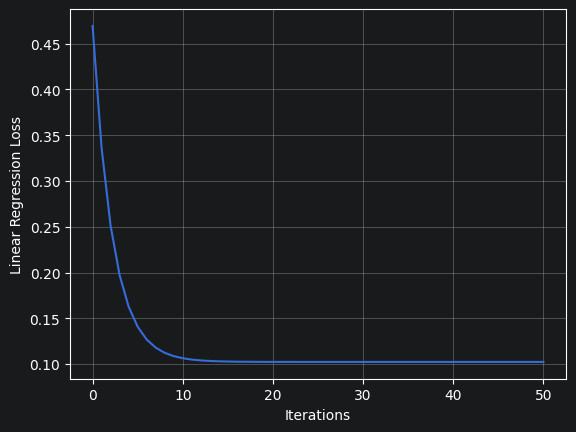

In [49]:
plt.plot(Linear_J_All)
plt.grid()
plt.xlabel('Iterations')
plt.ylabel('Linear Regression Loss')

### Step 4.3: Compute Linear Regression Predictions

Use the final Theta values and normalized features to form the prediction variable


In [50]:
### BEGIN SOLUTION

Linear_Predicted=_yp(*Linear_thetas)


### END SOLUTION

Run the following code block to see the actual values in blue and the predicted values in red. This is a great way to qualitatively visualize the results and verify your code.

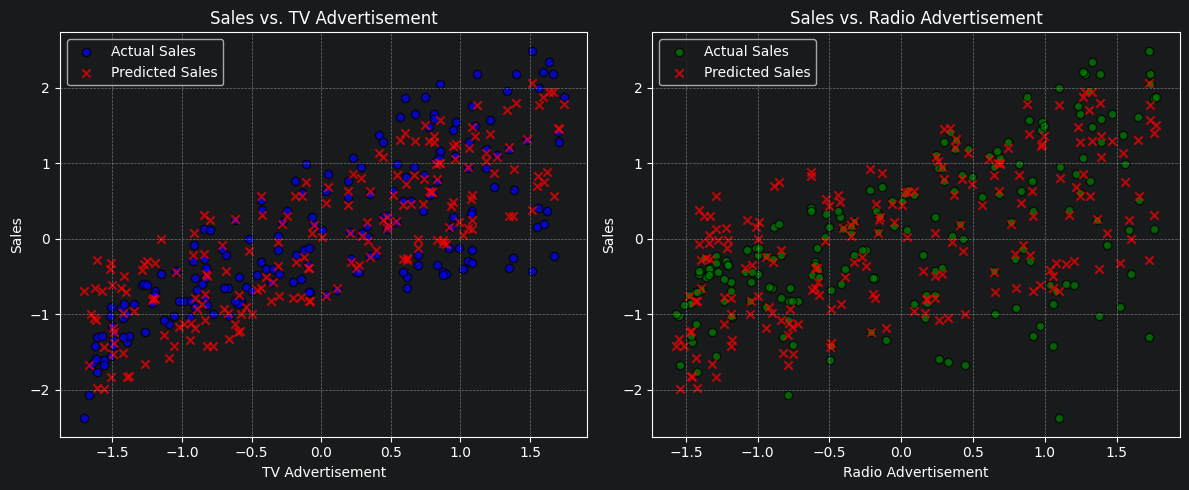

In [51]:
plt.figure(figsize=(12,5))

# --- Plot for TV ---
plt.subplot(1,2,1)
plt.scatter(X1_N, Y_N, color='blue', label='Actual Sales', alpha=0.7, edgecolors='k')
plt.scatter(X1_N, Linear_Predicted, color='red', label='Predicted Sales', alpha=0.7, marker='x')
plt.xlabel('TV Advertisement')
plt.ylabel('Sales')
plt.title('Sales vs. TV Advertisement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- Plot for Radio ---
plt.subplot(1,2,2)
plt.scatter(X2_N, Y_N, color='green', label='Actual Sales', alpha=0.7, edgecolors='k')
plt.scatter(X2_N, Linear_Predicted, color='red', label='Predicted Sales', alpha=0.7, marker='x')
plt.xlabel('Radio Advertisement')
plt.ylabel('Sales')
plt.title('Sales vs. Radio Advertisement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

Run the code block below to calculate absolute difference between your predictions and actual valurs (residuals) and then plot the histogram of these residuals which is a measure to compare different models. We will generate a new histogram later for the polinomial regression and see how its better than this one.

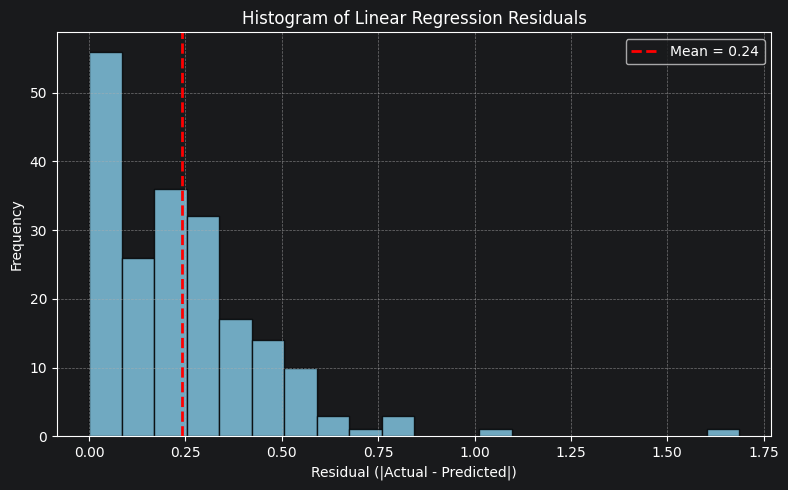

In [52]:
Linear_Residuals = abs(Y_N - Linear_Predicted)

plt.figure(figsize=(8,5))
plt.hist(Linear_Residuals, bins=20, color='skyblue', edgecolor='black', alpha=0.8)

# Labels and title
plt.xlabel('Residual (|Actual - Predicted|)')
plt.ylabel('Frequency')
plt.title('Histogram of Linear Regression Residuals')

# Grid
plt.grid(True, linestyle='--', alpha=0.6)

# Add vertical lines for mean and median
plt.axvline(np.mean(Linear_Residuals), color='red', linestyle='dashed', linewidth=2, label=f"Mean = {np.mean(Linear_Residuals):.2f}")

plt.legend()
plt.tight_layout()
plt.show()

## Step 5: Polynomial Regression (degree 2)

In this section, we would like to build our regression prediction model using a polynomial regression with degreee of 2:

>$$Sales=\theta_0+\theta_1(TV Advertisement)+\theta_2(TV Advertisement)^2+\theta_3(Radio Advertisement)+\theta_4(Radio Advertisement)^2$$<Font color=blue>$$+\theta_5(TV Advertisement)(Radio Advertisement)$$</Font>

1.   In the code block below, we have a list named thetas that in this case should contain 6 values: $$\theta_0,\theta_1,\theta_2,\theta_3,\theta_4,\theta_5$$ Initialize the theta parameters by filling the values in the list selecting a number between 0 to 0.5 for all Thetas. You will have to change these values over and over till you get the result you want.

2.   Initialize the learning rate eta $$\eta$$ as a value between 0 and 0.1. You will have to change the learning rate over and over till you get the result you want.

3.  Form the loss function (Mean squared error) as below:

>>$J= \frac{1}{Data Size}\sum_{Data} (\hat{y}-y)^2$

>>>$\hat{y}$ is the predicted value

>>>$y$ is the actual value

4.  Form the deravatives of Loss (J) with respect to Thetas:

>>$Jt0 = \frac{dJ}{d\theta_0}$<br>
>>$Jt1 = \frac{dJ}{d\theta_1}$<br>
>>$Jt2 = \frac{dJ}{d\theta_2}$<br>
>>$Jt3 = \frac{dJ}{d\theta_3}$<br>
>>$Jt4 = \frac{dJ}{d\theta_4}$<br>
>>$Jt5 = \frac{dJ}{d\theta_5}$

5.  Form the iterative procedure in which Theta values are updated based on the derivatives (Gradient Descent).

<font color='red'> Important notes:


*   It is important that you do not change the variable names in the code below
*   When your code finishes, you need to have the final Theta values in a list called Theta; the first elelement of the list should be theta0, the second item of the list should be theta1,...
*   You need to have a variable called J_All which records the J values as your iterative procedure runs (Append J value to the list in each iteration) so you can plot J_All in the next step.  
*   The iterative procedure goes through all data as many times as you want (Select a number larger than 100 and below 10000)
*   Dont forget to use the normalized features

In [54]:
### BEGIN SOLUTION
_X_N = np.vstack([np.ones(N), X1_N, X1_X1_N, X2_N, X2_X2_N, X1_X2_N]).T
N_iters = 501 # Because the check below says >500, even though the instructions above say: >100, <1000

def _yp2(th: np.ndarray) -> np.ndarray:
    return _X_N @ th

def _J2(th: np.ndarray) -> float:
    return 1 / N * np.sum((_yp2(th) - Y_N) ** 2)

def _dJ2_dt0(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*1)

def _dJ2_dt1(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*X1_N)

def _dJ2_dt2(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*X1_X1_N)

def _dJ2_dt3(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*X2_N)

def _dJ2_dt4(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*X2_X2_N)

def _dJ2_dt5(th: np.ndarray) -> float:
    return 1 / N *np.sum(2*(_yp2(th) - Y_N)*X1_X2_N)

def _grad_J2(th: np.ndarray) -> np.ndarray:
    return np.array([_dJ2_dt0(th), _dJ2_dt1(th), _dJ2_dt2(th), _dJ2_dt3(th), _dJ2_dt4(th), _dJ2_dt5(th)])


def _grad_desc_2(x0, eta_lr, n_iters: int = 101):
    loss_hist = []
    for _ in range(n_iters):
        loss_hist.append(_J2(x0))
        _gJ = _grad_J2(x0)
        x0 -= eta_lr * _gJ
    return x0, loss_hist


def _eval_candidate_2(theta_0, eta_c, best_eta, best_theta, best_loss_hist, n_iters: int = 101):
    theta_1, theta_loss_hist = _grad_desc_2(theta_0, eta_c, n_iters)
    # Save the result if it is absolutely better, or actually faster.
    if (theta_loss_hist[-1] < best_loss_hist[-1]) or (theta_loss_hist[-1] == best_loss_hist[-1] and eta_c > best_eta):
        best_theta = theta_1
        best_loss_hist = theta_loss_hist
        best_eta = eta_c

    return best_eta, best_theta, best_loss_hist


def find_poly_soln():
    # Brute force solution because my computer is fast. :)
    best_loss_hist = [np.inf]
    best_theta = None
    best_eta = None

    # Just randomly perform some samples, it doesn't matter THAT much.
    eta_lr = 0.099 # Since this is continuous, differentiable, positive semi-definite, just use the largest learning rate.
    for _ in range(100):
        # Experimentation says eta should be 0.099.
        best_eta, best_theta, best_loss_hist = _eval_candidate_2(np.random.rand(6)*0.5, eta_lr, best_eta, best_theta, best_loss_hist)

    # Now do the full 501 so the check below passes even though it's not needed.
    best_eta, best_theta, best_loss_hist = _eval_candidate_2(np.random.rand(6)*0.5, eta_lr, best_eta, best_theta, best_loss_hist, n_iters=750)
    return best_theta, best_eta, best_loss_hist



# Convert back to the expected variables (one of which do not follow python conventions)
theta, eta, J_All = find_poly_soln()
print("Thetas=", theta)

### END SOLUTION

Thetas= [-2.64407411e-16  8.29962514e-01 -5.30192414e-01  7.23790746e-02
  2.78856654e-02  6.94175142e-01]


### Step 5.1: Verify Your Polinomial Regression Settings

Run the following code block and make sure:
* The first line prints the eta value you selected.  
* The second line checks the number of thetas you have, and therefore it should print **True**.  
* The third line verifies that you had more than 500 iterations, and therefore it should also print **True**.  

In [41]:
print (eta)
print (len(theta)==6)
print (len(J_All)>500)

0.099
True
True


### Step 5.2: Create a Loss Plot

Run the following code to generate a plot of the loss (error) as gradient descent runs.
*   The x-axis shows the number of iterations.
*   The y-axis shows the loss value.
*   A well-behaved model should show the loss decreasing steadily as the number of iterations increases.

👉 If the curve is still going down at the far right of your plot, it means the model has not converged yet. In that case, go back to the previous step and try one or more of the following:

1.   Increase the number of iterations so the algorithm has more time to converge.
2.   Adjust the learning rate (eta) — if it’s too high, the loss may bounce around; if it’s too low, convergence may be very slow.
3.   Change the initialization values of θ (the parameters) — sometimes a poor starting point delays convergence.

✅ Your goal: the right side of the plot should become flat, showing that the loss has stabilized and gradient descent has converged.

Text(0, 0.5, 'Polynomial Regression Loss')

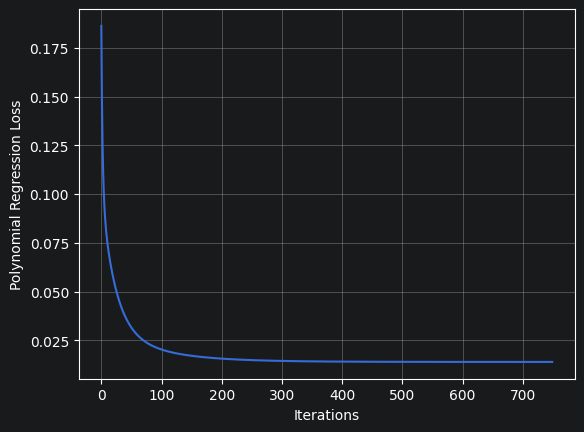

In [42]:
plt.plot(J_All)
plt.grid()
plt.xlabel('Iterations')
plt.ylabel('Polynomial Regression Loss')

### Step 5.3: Compute Polynomial Regression Predictions

Use the final Theta values and normalized features to form the prediction variable


In [43]:
### BEGIN SOLUTION

Predicted= _yp2(theta)


### END SOLUTION

Run the following code block to see the actual values in blue and the predicted values in red. This is a great way to qualitatively visualize the results and verify your code.

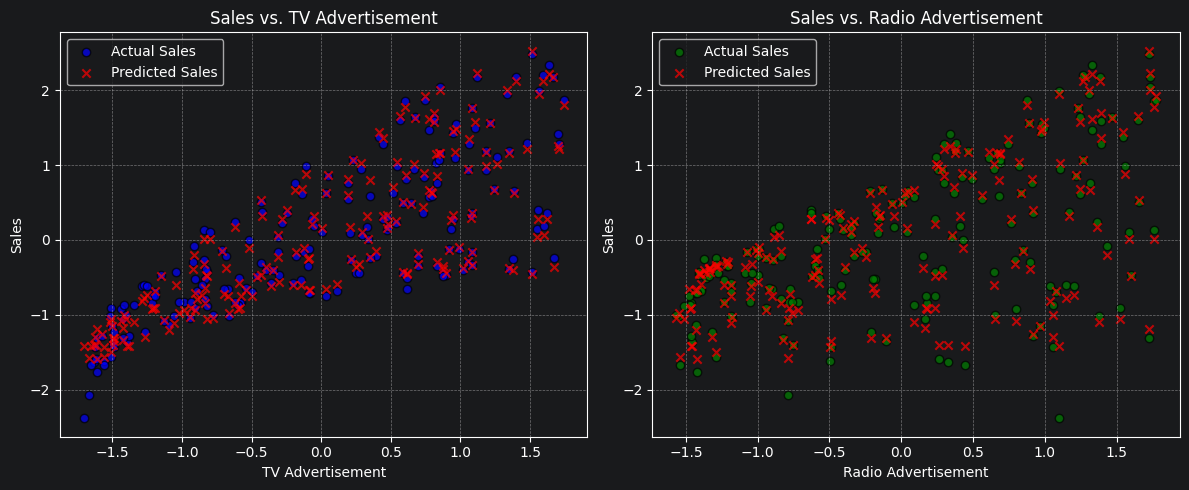

In [44]:
plt.figure(figsize=(12,5))

# --- Plot for TV ---
plt.subplot(1,2,1)
plt.scatter(X1_N, Y_N, color='blue', label='Actual Sales', alpha=0.7, edgecolors='k')
plt.scatter(X1_N, Predicted, color='red', label='Predicted Sales', alpha=0.7, marker='x')
plt.xlabel('TV Advertisement')
plt.ylabel('Sales')
plt.title('Sales vs. TV Advertisement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- Plot for Radio ---
plt.subplot(1,2,2)
plt.scatter(X2_N, Y_N, color='green', label='Actual Sales', alpha=0.7, edgecolors='k')
plt.scatter(X2_N, Predicted, color='red', label='Predicted Sales', alpha=0.7, marker='x')
plt.xlabel('Radio Advertisement')
plt.ylabel('Sales')
plt.title('Sales vs. Radio Advertisement')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

##Step 6 Compare Residuals using Histograms

Run the code block below to calculate the absolute difference between your predictions and the actual values (residuals), and then plot the histograms of these residuals. Residual histograms are a useful way to **compare how well different models fit the data.**

In this case, we overlay two histograms on the same plot:
	•	**Linear regression residuals** (baseline model)
	•	**Polynomial regression residuals** (enhanced model)

By comparing the two, you can visually see whether the polynomial model produces **smaller and more concentrated residuals** than the linear model. If the polynomial regression histogram is shifted more toward the left (closer to zero), it means it fits the data better.

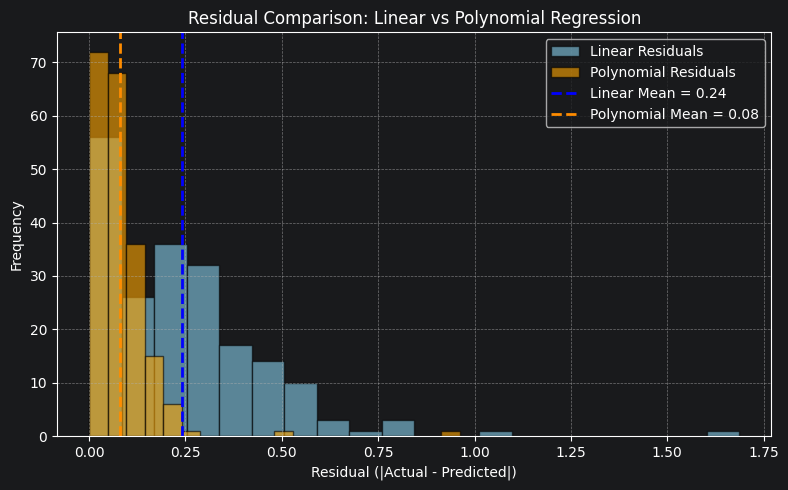

In [45]:
# Residuals
Linear_Residuals = abs(Y_N - Linear_Predicted)
Poly_Residuals   = abs(Y_N - Predicted)

plt.figure(figsize=(8,5))

# Linear regression residuals
plt.hist(Linear_Residuals, bins=20, color='skyblue', edgecolor='black',
         alpha=0.6, label='Linear Residuals')

# Polynomial regression residuals
plt.hist(Poly_Residuals, bins=20, color='orange', edgecolor='black',
         alpha=0.6, label='Polynomial Residuals')

# Labels and title
plt.xlabel('Residual (|Actual - Predicted|)')
plt.ylabel('Frequency')
plt.title('Residual Comparison: Linear vs Polynomial Regression')

# Grid
plt.grid(True, linestyle='--', alpha=0.6)

# Mean lines
plt.axvline(np.mean(Linear_Residuals), color='blue', linestyle='dashed', linewidth=2,
            label=f"Linear Mean = {np.mean(Linear_Residuals):.2f}")
plt.axvline(np.mean(Poly_Residuals), color='darkorange', linestyle='dashed', linewidth=2,
            label=f"Polynomial Mean = {np.mean(Poly_Residuals):.2f}")

plt.legend()
plt.tight_layout()
plt.show()

**Good Job!**

I hope you can see the major improvement achieved by using polynomial regression. In every regression problem, we typically start with linear regression as a baseline and then move on to more advanced models for better performance.
